In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
with open('data/names.txt') as fobj:
    names = fobj.read().split('\n') # split file context at newline
# map letters to integer indices, including '.' (end-of-word character)
# this will help us build a transition matrix
alphabet = ".abcdefghijklmnopqrstuvwxyz"
idx = {letter:index for index, letter in enumerate(alphabet)}
idx

all_names = '.'+'.'.join(names)
all_idxs = [idx[c] for c in all_names]
all_names[:15], all_idxs[:15]

('.emma.olivia.av', [0, 5, 13, 13, 1, 0, 15, 12, 9, 22, 9, 1, 0, 1, 22])

In [2]:
# create 'codebook', the lookup table for character encodings
embed_dim = 2
C = torch.randn((27, embed_dim), requires_grad=True)
# copy the initial embedding vectors so we can compare to what they become after training
C_init = C.detach().numpy().copy()

# create the dataset
window = 3 # length of context window
X, Y = [], [] # lists to hold input and output data
N = len(all_idxs)

for k in range(N - window - 1):
    X.append(all_idxs[k : k+window])
    Y.append(all_idxs[k + window])

X = torch.tensor(X)
Y = torch.tensor(Y)

In [4]:
X[:5], Y[:5]

(tensor([[ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1],
         [13,  1,  0],
         [ 1,  0, 15]]),
 tensor([13,  1,  0, 15, 12]))

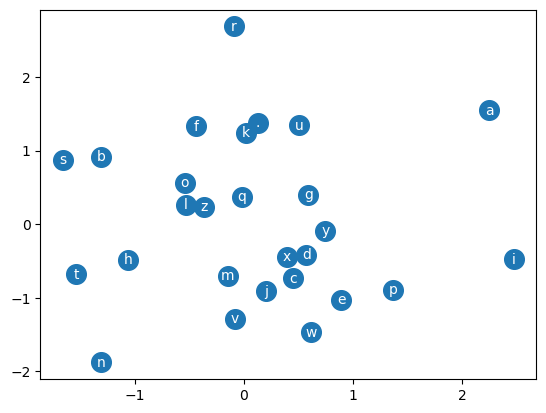

In [5]:
# write a function to visualize the character embedding
def plot_char_embedding(C_in, alphabet=alphabet):
    if type(C_in) == torch.Tensor:
        C = C_in.detach().numpy()
    else:
        C = C_in
    plt.scatter(*C.T, s=200)
    for i, char in enumerate(alphabet):
        plt.text(C[i, 0], C[i, 1], char, color='white', ha='center', va='center')

plot_char_embedding(C_init, alphabet)

In [6]:
C[X].shape

torch.Size([228142, 3, 2])

In [8]:
C[X].view((-1, window*embed_dim)).shape

torch.Size([228142, 6])

In [9]:
hidden_dim = 200 # number of hidden units

W1 = torch.randn((window * embed_dim, hidden_dim), requires_grad=True)
b1 = torch.randn(hidden_dim, requires_grad=True)

W2 = torch.randn((hidden_dim, 27), requires_grad=True)
b2 = torch.randn(27, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [10]:
# forward pass

hidden_activations = (C[X].view((-1, window * embed_dim)) @ W1 + b1).tanh()
logits = (hidden_activations @ W2 + b2)

loss = F.cross_entropy(logits, Y)
loss.item()

27.17574119567871

In [12]:

# apply GD in a loop
h = 0.1 # step size
for step in range(10):
    for p in parameters:
        p.grad = None
    hidden_activations = (C[X].view((-1, window * embed_dim)) @ W1 + b1).tanh()
    logits = (hidden_activations @ W2 + b2)

    loss = F.cross_entropy(logits, Y)
    print(loss.item())

    loss.backward()
    for p in parameters:
        p.data -= h * p.grad

16.294723510742188
15.63974380493164
15.046566009521484
14.499346733093262
13.989599227905273
13.509634971618652
13.055503845214844
12.62393856048584
12.211538314819336
11.814920425415039


In [13]:
loss_values = []

In [24]:
# SGD, i.e. do minibatches
# apply GD in a loop
h = 0.001 # step size

for step in range(10000):
    for p in parameters:
        p.grad = None
    
    # minibatch selection
    batch_idxs = torch.randint(0, X.shape[0], (64,)) # low, high, shape
    hidden_activations = (C[X[batch_idxs]].view((-1, window * embed_dim)) @ W1 + b1).tanh()
    logits = (hidden_activations @ W2 + b2)

    loss = F.cross_entropy(logits, Y[batch_idxs])
    loss_values.append(loss.item())
    if step % 100 == 0:
        print(loss.item())

    loss.backward()
    for p in parameters:
        p.data -= h * p.grad

2.358680486679077
2.3722293376922607
2.3843472003936768
2.5574166774749756
2.480562925338745
2.349175453186035
2.5498361587524414
2.5201432704925537
2.301783561706543
2.673525810241699
2.3705313205718994
2.5666463375091553
2.5472843647003174
2.801490068435669
2.5609207153320312
2.629499912261963
2.5112578868865967
2.3511312007904053
2.5054144859313965
2.257534980773926
2.476998805999756
2.282867908477783
2.2859091758728027
2.406914710998535
2.205244302749634
2.34303879737854
2.657510995864868
2.412327289581299
2.3308446407318115
2.389113664627075
2.483405590057373
2.6196682453155518
2.6537630558013916
2.6722569465637207
2.1735761165618896
2.7240262031555176
2.313702344894409
2.4316213130950928
2.6112918853759766
2.3356945514678955
2.450747013092041
2.4068591594696045
2.2504141330718994
2.4466183185577393
2.6317126750946045
2.422928810119629
2.291343927383423
2.6861259937286377
2.542586088180542
2.247394323348999
2.2769722938537598
2.3603179454803467
2.3757741451263428
2.412011623382568

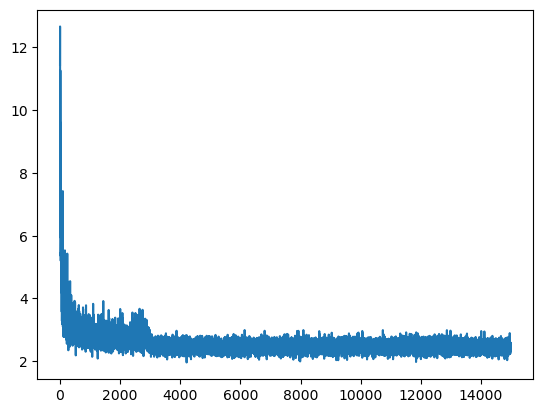

In [25]:
plt.plot(loss_values)

In [26]:
# sample from the model!

def embed(word):
    idxs = torch.tensor([idx[c] for c in word])
    xenc = C[idxs]
    return xenc.view(-1, len(word)*embed_dim)

def generate(starting_word = "..."):
    word = starting_word
    done = False

    while not done:
        # grab the window of appropriate length
        context = embed(word[-window:])

        # apply the NN function
        hidden_activations = (context @ W1 + b1).tanh()
        logits = hidden_activations @ W2 + b2

        # convert outputs to probabilities (subtract max to ensure numerical stability) Do we actually have to do this?
        next_char_probs = F.softmax(logits - logits.max(), dim=1)
        # sample the next letter according to probs
        next_idx = torch.multinomial(next_char_probs, 1)
        next_char = alphabet[next_idx]
        if next_char == '.':
            done = True
        word = word + next_char
    return word


In [30]:
for _ in range(5):
    print(generate().replace(".",""))

ren
lin
ycsbhesyilar
xashnen
iyenn


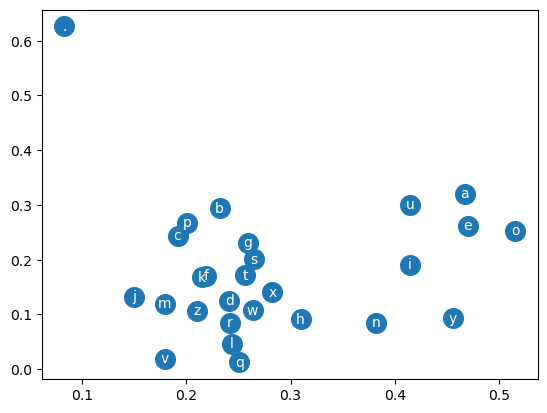

In [31]:
plot_char_embedding(C)

In [32]:
# can we interpret this embedding another way?
# predictive equivalence???

# idea: tabulate all triples of letters and compute next-char probabilities for them according to the NN
# average over all letter triples that share a last letter to get a 27 x 27 matrix
# do PCA on the matrix and project down to 2 dimensions, then plot

with torch.no_grad():

    Pmat = torch.zeros((27, 27))
    for i, char in enumerate(alphabet):
        all_words_ending_in_char = list()
        for char1 in alphabet:
            for char2 in alphabet:
                all_words_ending_in_char.append(char1+char2+char)
        p_avg = torch.zeros(27)
        for word in all_words_ending_in_char:
            context = embed(word)

            # apply the NN function
            hidden_activations = (context @ W1 + b1).tanh()
            logits = hidden_activations @ W2 + b2

            # convert outputs to probabilities (subtract max to ensure numerical stability) Do we actually have to do this?
            next_char_probs = F.softmax(logits - logits.max(), dim=1).squeeze()
            p_avg += next_char_probs
        Pmat[i, :] = p_avg / len(all_words_ending_in_char)

In [33]:
from sklearn.decomposition import PCA

pca = PCA(2)
prob_pca = pca.fit_transform(Pmat)

prob_pca

array([[ 0.0679294 , -0.21029566],
       [ 0.28620519, -0.00998566],
       [ 0.0149054 , -0.0944945 ],
       [-0.06867352, -0.05854231],
       [-0.09355188,  0.01437819],
       [ 0.27954934,  0.02414387],
       [-0.08927938, -0.0116713 ],
       [ 0.00435942, -0.04660876],
       [-0.02847871,  0.04456613],
       [ 0.19127733,  0.03777621],
       [-0.17845259,  0.00908268],
       [-0.09612457, -0.01054476],
       [-0.13737224,  0.0412453 ],
       [-0.16050453,  0.01263898],
       [ 0.07220378,  0.07140899],
       [ 0.32092053,  0.04985425],
       [-0.04032103, -0.07588072],
       [-0.14793365,  0.04854507],
       [-0.11793438,  0.03041596],
       [-0.00994667, -0.02469145],
       [-0.04227666, -0.00782383],
       [ 0.23150619, -0.02982894],
       [-0.20108382,  0.04387658],
       [-0.07762637,  0.02596286],
       [-0.02960182,  0.01559017],
       [ 0.18910791,  0.09211963],
       [-0.13880266,  0.018763  ]])

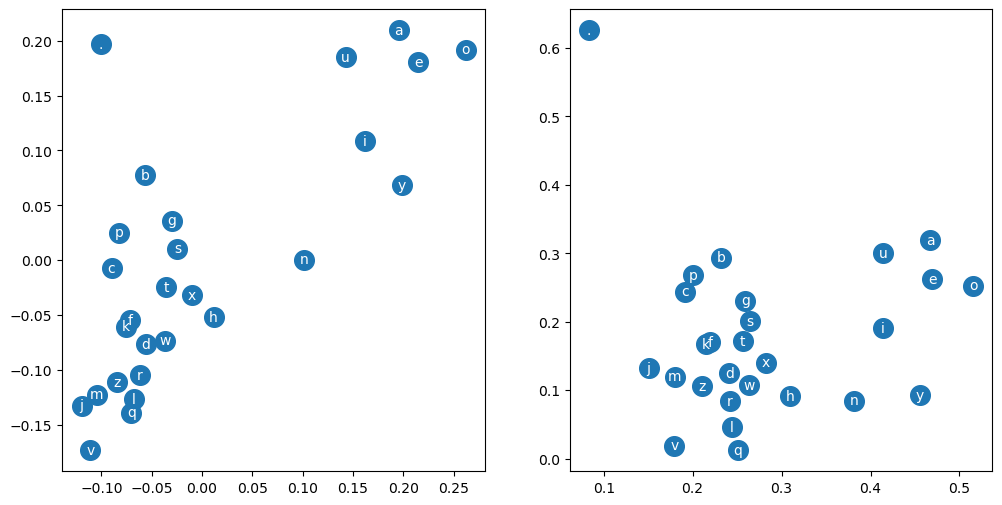

In [45]:
# rotate
theta = np.pi/4
rotn_matrix = np.array([[np.cos(theta), np.sin(theta)],[-np.sin(theta), np.cos(theta)]])
reflection_matrix = np.array([[0, 1], [1, 0]])

plt.figure(figsize=(12,6))
plt.subplot(121)
plot_char_embedding(prob_pca @ rotn_matrix @ reflection_matrix)
plt.subplot(122)
plot_char_embedding(C)